In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

In [2]:
# Chamar df e filtrar para nossa liga inicial
df_raw = pd.read_csv('cleaned_data/df_odds.csv', parse_dates=['date'], low_memory=False)

df_raw = df_raw[df_raw['league'] == 22614].copy()

In [3]:
from stktrain import split_data, input_averages

In [4]:
# Pré-processamento de dados
train_raw, test_raw = split_data(
    df=df_raw,
    split_date=datetime(2025,8,1),
    date_column='date'
)

In [5]:
# Agora temos as médias de 50 partidas para os jogadores
train_with_avg, test_with_avg = input_averages(train_raw, test_raw)

In [7]:
# Filtrar o dataframe
features = [
    "ma_home", "std_home",
    "ma_away", "std_away",
    "ma_h2h", "std_h2h"
]

X_train = train_with_avg[features]
y_train = train_with_avg['total_score']

X_test = test_with_avg[features]
y_test = test_with_avg['total_score']

In [ ]:
#### Rolling Cross-Fold Val

In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error

In [ ]:
X = X_train.values
y = y_train.values

window_size = int(0.2 * len(X))   
step_size = window_size           

rmse_scores = []
fold = 0

In [ ]:
def rolling_cv_rmse_train(X, y, window_size, step_size, params):
    rmse_scores = []
    for start in range(0, len(X) - window_size, step_size):
        end = start + window_size
        if end >= len(X):
            break

        X_tr, y_tr = X[start:end], y[start:end]
        X_val, y_val = X[end:end+step_size], y[end:end+step_size]

        if len(X_val) == 0:
            continue

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        # parâmetros para o xgb.train
        train_params = {
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "subsample": params["subsample"],
            "colsample_bytree": params["colsample_bytree"],
            "min_child_weight": params["min_child_weight"],
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "seed": 42,
        }

        evals = [(dval, "eval"), (dtrain, "train")]

        bst = xgb.train(
            params=train_params,
            dtrain=dtrain,
            num_boost_round=params["n_estimators"],
            evals=evals,
            early_stopping_rounds=30,
            verbose_eval=False
        )

        # usar melhor número de iterações encontrado
        best_boosters = bst.best_iteration + 1  # +1 porque best_iteration é 0-indexed

        # prever com esse número
        y_pred = bst.predict(dval, iteration_range=(0, best_boosters))
        rmse = root_mean_squared_error(y_val, y_pred)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
    }

    return rolling_cv_rmse_train(X, y, window_size, step_size, params)


In [ ]:

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)  # aumente n_trials para explorar mais

print("Melhores parâmetros encontrados:", study.best_params)
print("Melhor RMSE médio:", study.best_value)


In [ ]:
### TSCV normal
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error

X = X_train.values
y = y_train.values

def timeseries_cv_rmse(X, y, params, n_splits=5):
    rmse_scores = []
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for train_index, val_index in tscv.split(X):
        X_tr, X_val = X[train_index], X[val_index]
        y_tr, y_val = y[train_index], y[val_index]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        train_params = {
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "subsample": params["subsample"],
            "colsample_bytree": params["colsample_bytree"],
            "min_child_weight": params["min_child_weight"],
            "gamma": params["gamma"],
            "reg_alpha": params["reg_alpha"],
            "reg_lambda": params["reg_lambda"],
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "seed": 42,
        }

        evals = [(dval, "eval"), (dtrain, "train")]

        bst = xgb.train(
            params=train_params,
            dtrain=dtrain,
            num_boost_round=params["n_estimators"],
            evals=evals,
            early_stopping_rounds=30,
            verbose_eval=False
        )

        y_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration+1))
        rmse = root_mean_squared_error(y_val, y_pred)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
    }

    return timeseries_cv_rmse(X, y, params, n_splits=5)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Melhores parâmetros encontrados:", study.best_params)
print("Melhor RMSE médio:", study.best_value)


[I 2025-09-16 22:53:36,175] A new study created in memory with name: no-name-e6e19e19-61eb-4262-8d07-cfb233a1a5ac
[I 2025-09-16 22:53:41,696] Trial 0 finished with value: 2.3048041343688963 and parameters: {'n_estimators': 217, 'learning_rate': 0.07570927028311154, 'max_depth': 10, 'subsample': 0.7288844306824455, 'colsample_bytree': 0.9424179379232952, 'min_child_weight': 6, 'gamma': 0.29939505967891633, 'reg_alpha': 0.7932061559830167, 'reg_lambda': 4.932263840610937}. Best is trial 0 with value: 2.3048041343688963.
[I 2025-09-16 22:53:44,565] Trial 1 finished with value: 2.3107693672180174 and parameters: {'n_estimators': 673, 'learning_rate': 0.10556940790022214, 'max_depth': 6, 'subsample': 0.7480252370069727, 'colsample_bytree': 0.724648895425804, 'min_child_weight': 6, 'gamma': 2.923813602880856, 'reg_alpha': 0.43400649306916084, 'reg_lambda': 6.368511429688144}. Best is trial 0 with value: 2.3048041343688963.
[I 2025-09-16 22:53:47,257] Trial 2 finished with value: 2.2121033668

Melhores parâmetros encontrados: {'n_estimators': 418, 'learning_rate': 0.014280451319598729, 'max_depth': 3, 'subsample': 0.798225181825874, 'colsample_bytree': 0.6174548905825178, 'min_child_weight': 3, 'gamma': 2.627366203873275, 'reg_alpha': 0.9948380056925294, 'reg_lambda': 9.979678551493626}
Melhor RMSE médio: 2.1953783988952638


In [9]:

# ==============================
# Treinar no dataset completo e avaliar no holdout
params = {
    'n_estimators': 418,
    'learning_rate': 0.014280451319598729,
    'max_depth': 3,
    'subsample': 0.798225181825874,
    'colsample_bytree': 0.6174548905825178,
    'min_child_weight': 3,
    'gamma': 2.627366203873275,
    'reg_alpha': 0.9948380056925294,
    'reg_lambda': 9.979678551493626
    }



# ==============================
final_model = xgb.XGBRegressor(**params)

final_model.fit(X, y)

X_holdout = X_test.values
y_holdout = y_test.values

y_pred_holdout = final_model.predict(X_holdout)
rmse_holdout = root_mean_squared_error(y_holdout, y_pred_holdout)

print(f"\nRMSE no Holdout: {rmse_holdout:.4f}")



RMSE no Holdout: 2.2088


In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df)

    feature  importance
3  std_away    0.037764
1  std_home    0.041281
5   std_h2h    0.058675
0   ma_home    0.197331
2   ma_away    0.198063
4    ma_h2h    0.466887


In [13]:
from scipy.stats import poisson

test_with_avg['pred'] = y_pred_holdout
df = test_with_avg.copy()

In [14]:
# Agora vamos calcular todas as probabilidades para o modelo

def poisson_goals(
    lambda_pred: float,
    handicap: float
    ) -> tuple[float, float]:

    """
    Calculate the Probability of a given Goal Line (Handicap).
    TODO: Create Poisson Probabilities for other markets.
    """
    def half_goal_handicap(handicap, lambda_pred) -> tuple[float,float]:
        prob_over = 1 - (poisson.cdf(int(handicap), lambda_pred))
        prob_under = (poisson.cdf(int(handicap), lambda_pred))
        
        return float(prob_over), float(prob_under)
    
    def integer_handicap(handicap,lambda_pred) -> tuple[float,float]:
        prob_over_raw = 1 - (poisson.cdf(int(handicap), lambda_pred))
        prob_under_raw = (poisson.cdf(int(handicap) - 1, lambda_pred))
        
        total = prob_over_raw + prob_under_raw
        
        prob_over = prob_over_raw / total
        prob_under = prob_under_raw / total

        return float(prob_over), float(prob_under)
    
    def quarter_handicap(handicap,lambda_pred) -> tuple[float,float]:
        
        lower = handicap - 0.25
        upper = handicap + 0.25
        probs_over = []
        probs_under = []

        for line in lower, upper:
            if line % 1 == 0.5:
                over, under = half_goal_handicap(
                handicap=line,
                lambda_pred=lambda_pred
            )
                
            elif line % 1 == 0.0:  
                over, under = integer_handicap(
                handicap=line,
                lambda_pred=lambda_pred
            )
            
            probs_over.append(over)
            probs_under.append(under)
        
        prob_over = sum(probs_over) / len(probs_over) 
        prob_under = sum(probs_under) / len(probs_under)
        
        return float(prob_over), float(prob_under)

    if handicap % 1 == 0.5:
        prob_over, prob_under = half_goal_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )

    elif handicap % 1 == 0.0:  
        prob_over, prob_under = integer_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )

    elif handicap % 1 in [0.25, 0.75]:  
        prob_over, prob_under = quarter_handicap(
            handicap=handicap,
            lambda_pred=lambda_pred
        )
    
    else:
        print(f'Invalid Handicap used to estimate goal probabilities: {handicap}')
        raise ValueError(f"Handicap inválido: {handicap}")
    
    return prob_over, prob_under


def profit(bet_type: str, handicap: float, total_score: int, bet_odd: float) -> float:
    
    """
    Calcular o PL dado um tipo de aposta, handicap, odd e resultado.
    TODO: Permitir outros mercados.
    TODO: Permitir stake variável.
    """

    if bet_type.lower() == 'over': outcome = total_score - handicap
    elif bet_type.lower() == 'under': outcome = handicap - total_score

    try:
        if outcome >= 0.5: 
            profit = (bet_odd - 1)
            result = 'win' 
        
        elif outcome == 0.25:
            profit = (bet_odd - 1) / 2
            result = 'half_win'

        elif outcome == 0: 
            profit = 0
            result = 'push'
        
        elif outcome == -0.25:
            profit = -0.5
            result = 'half_loss'

        
        elif outcome <= -0.5: 
            profit = -1
            result = 'loss'
        
        return profit
        
    except: 
        print(f"Ajuste de resultado inválido: {outcome}")
        return 0


def ev(odd, prob):
    return odd * prob -1

def goal_handicap(handicap) -> float | None:

    """
    Gets the handicap from the API and solves type errors,
    Also, converts it to a float and returns the current handicap if successful.
    """

    try: 
        if isinstance(handicap, str):
            if ',' in handicap:
                handicap_vals = [float(h.strip()) for h in handicap.split(',')]
                handicap = sum(handicap_vals) / len(handicap_vals)
            
            else:
                handicap = float(handicap.strip())
        
        return handicap
    
    except ValueError as ve:
        print(f"Error converting handicap '{handicap}': {ve}")


In [18]:
# Criar DF de Backtesting
df['1_3_handicap'] = df['1_3_handicap'].apply(goal_handicap)

# transformar valores inválidos em NaN e converter para float
cols = ['1_3_handicap', '1_3_over_od', '1_3_under_od', 'total_score', 'pred']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # inválidos → NaN

# extrair colunas como arrays NumPy
handicap = df['1_3_handicap'].values
over_od = df['1_3_over_od'].values
under_od = df['1_3_under_od'].values
total_score = df['total_score'].values
pred = df['pred'].values

# calcular probabilidades (somente onde não é NaN)
valid_mask = ~(
    np.isnan(handicap) |
    np.isnan(over_od) |
    np.isnan(under_od) |
    np.isnan(total_score) |
    np.isnan(pred)
)

probs = np.full((len(df), 2), np.nan)  # inicializa com NaN
probs[valid_mask] = np.array([
    poisson_goals(p, h) for p, h in zip(pred[valid_mask], handicap[valid_mask])
])
prob_over = probs[:, 0]
prob_under = probs[:, 1]

# expectativa de valor
ev_over = np.full(len(df), np.nan)
ev_over[valid_mask] = [ev(o, prob) for o, prob in zip(over_od[valid_mask], prob_over[valid_mask])]

ev_under = np.full(len(df), np.nan)
ev_under[valid_mask] = [ev(u, prob) for u, prob in zip(under_od[valid_mask], prob_under[valid_mask])]

# inicializar arrays de saída
ev_bet = np.full(len(df), np.nan)
bet_type = np.full(len(df), None, dtype=object)
bet_profit = np.full(len(df), np.nan)

# escolher entre over e under
mask_over = valid_mask & (ev_over > ev_under) & (ev_over > 0)
mask_under = valid_mask & (ev_under >= ev_over) & (ev_under > 0)

# quando over é melhor
ev_bet[mask_over] = ev_over[mask_over]
bet_type[mask_over] = "over"

bet_profit[mask_over] = [
    profit("over", h, ts, o)
    for h, ts, o in zip(handicap[mask_over], total_score[mask_over], over_od[mask_over])
]

# quando under é melhor
ev_bet[mask_under] = ev_under[mask_under]
bet_type[mask_under] = "under"
bet_profit[mask_under] = [
    profit("under", h, ts, o)
    for h, ts, o in zip(handicap[mask_under], total_score[mask_under], under_od[mask_under])
]

# salvar no dataframe
df['over_prob'] = prob_over
df['under_prob'] = prob_under
df['ev_over'] = ev_over
df['ev_under'] = ev_under
df['ev_bet'] = ev_bet
df['bet_type'] = bet_type
df['bet_profit'] = bet_profit

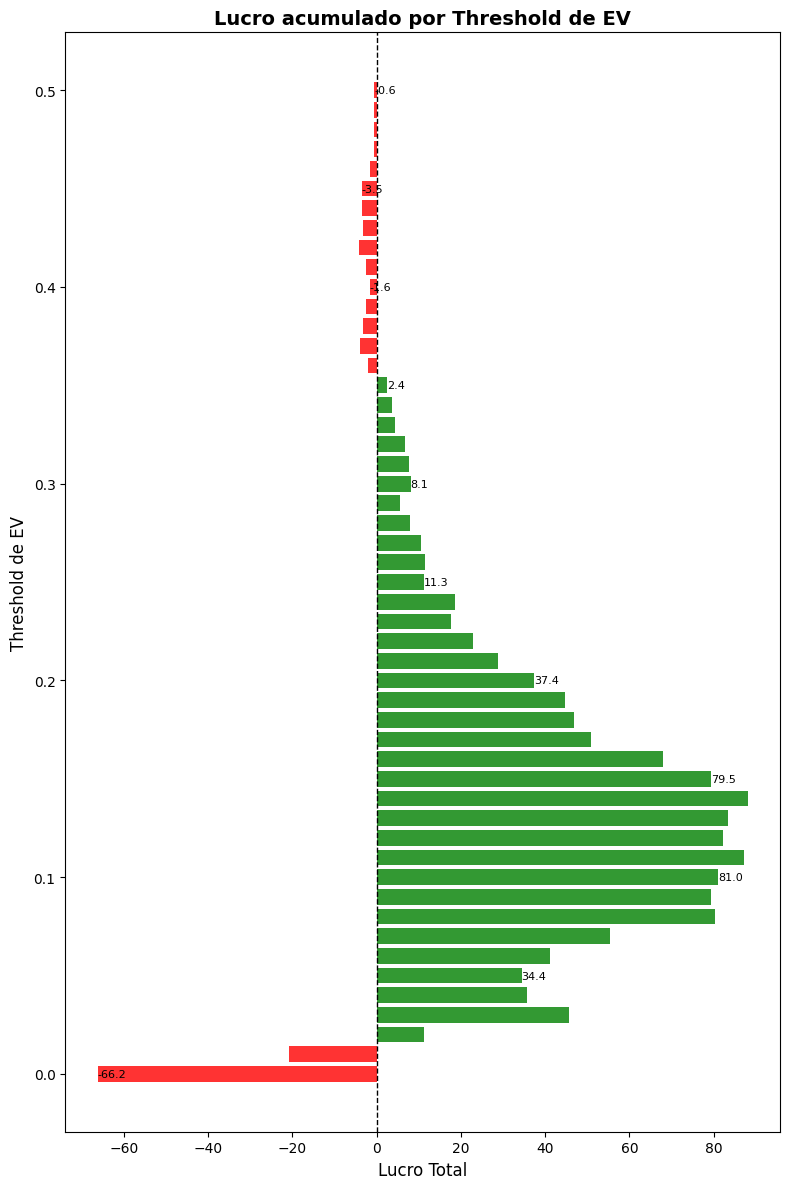

In [23]:
#Plotar Resultados por TS
def lucro_por_threshold(df, step=0.01, max_threshold=1.0):
    """
    Calcula métricas por threshold de EV:
      - Lucro total
      - ROI (lucro / número de apostas)

    Espera colunas:
        'ev_bet' : valor esperado
        'bet_profit' : lucro/prejuízo da aposta
    """
    thresholds = np.arange(0, max_threshold + step, step)
    results = []

    for t in thresholds:
        mask = df['ev_bet'] >= t
        df_filtrado = df.loc[mask]

        total_profit = df_filtrado['bet_profit'].sum(skipna=True)
        num_bets = df_filtrado.shape[0]

        roi = total_profit / num_bets if num_bets > 0 else np.nan

        results.append({
            "threshold": round(t, 2),
            "total_profit": total_profit,
            "roi": roi
        })

    return pd.DataFrame(results)


resultados = lucro_por_threshold(df, step=0.01, max_threshold=0.5)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,12))

# cores: verde se lucro > 0, vermelho se <= 0
colors = np.where(resultados['total_profit'] >= 0, 'green', 'red')

bars = plt.barh(
    resultados['threshold'],
    resultados['total_profit'],
    height=0.008,
    align='center',
    color=colors,
    alpha=0.8
)

# linha de referência vertical em x=0
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# títulos e labels
plt.ylabel("Threshold de EV", fontsize=12)
plt.xlabel("Lucro Total", fontsize=12)
plt.title("Lucro acumulado por Threshold de EV", fontsize=14, weight="bold")

# rótulos numéricos no fim das barras (a cada 5 thresholds)
for bar in bars[::5]:
    width = bar.get_width()
    if not np.isnan(width):
        plt.text(
            width,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}",
            ha='left', va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()


In [25]:
def desempenho_por_data(df, ev_ts: float) -> pd.DataFrame:
    """
    Calcula métricas diárias aplicando um threshold de EV.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com colunas:
          - 'date' (datetime)
          - 'ev_bet' (valor esperado da aposta)
          - 'bet_profit' (lucro/prejuízo da aposta)
    ev_ts : float
        Threshold de EV (filtra apenas apostas com ev_bet >= ev_ts)

    Returns
    -------
    pd.DataFrame
        Índice = datas
        Colunas:
          - 'total_profit' : lucro do dia
          - 'num_bets' : número de apostas do dia
          - 'roi' : lucro / nº de apostas
          - 'saldo_acumulado' : lucro acumulado ao longo dos dias
    """
    # filtrar pelas apostas acima do threshold
    df_filtrado = df.loc[df['ev_bet'] >= ev_ts].copy()

    # agrupar por data
    daily = (
        df_filtrado
        .groupby(df_filtrado['date'].dt.date)
        .agg(
            total_profit=("bet_profit", "sum"),
            num_bets=("bet_profit", "count")
        )
    )

    # calcular ROI e saldo acumulado
    daily["roi"] = daily["total_profit"] / daily["num_bets"]
    daily["saldo_acumulado"] = daily["total_profit"].cumsum()

    return daily.reset_index().rename(columns={"date": "data"})

df_resultados = desempenho_por_data(df, ev_ts=0.15)
df_resultados


,data,total_profit,num_bets,roi,saldo_acumulado
0,2025-08-01,2.1250,22,0.096591,2.1250
1,2025-08-02,1.4250,16,0.089063,3.5500
2,2025-08-03,4.2750,6,0.712500,7.8250
3,2025-08-04,0.7250,17,0.042647,8.5500
4,2025-08-05,4.4000,16,0.275000,12.9500
5,2025-08-06,1.9875,22,0.090341,14.9375
6,2025-08-07,3.0000,14,0.214286,17.9375
7,2025-08-08,-1.0375,20,-0.051875,16.9000
8,2025-08-09,-0.6500,17,-0.038235,16.2500
9,2025-08-10,3.1125,17,0.183088,19.3625


In [17]:
# Salvar no Excel
df.to_excel('basexgb.xlsx', index=False)